In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


In [10]:
df = pd.read_csv('C:\\Users\\Rahel\\Desktop\\KAIM 5&6\\week 1\\Predicting-Stock-Price-Movement-from-Financial-News-Sentiment\\data\\raw_analyst_ratings.csv')
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [11]:
# Overview
df.info()

# Summary stats
df.describe(include='all')

# Missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

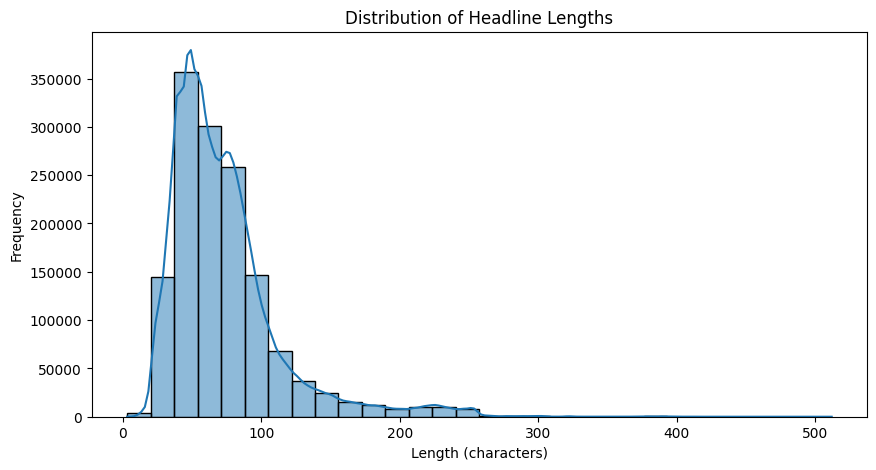

In [12]:
# Headline character length
df['headline_length'] = df['headline'].astype(str).apply(len)

# Summary
df['headline_length'].describe()

# Plot
plt.figure(figsize=(10, 5))
sns.histplot(df['headline_length'], bins=30, kde=True)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.show()


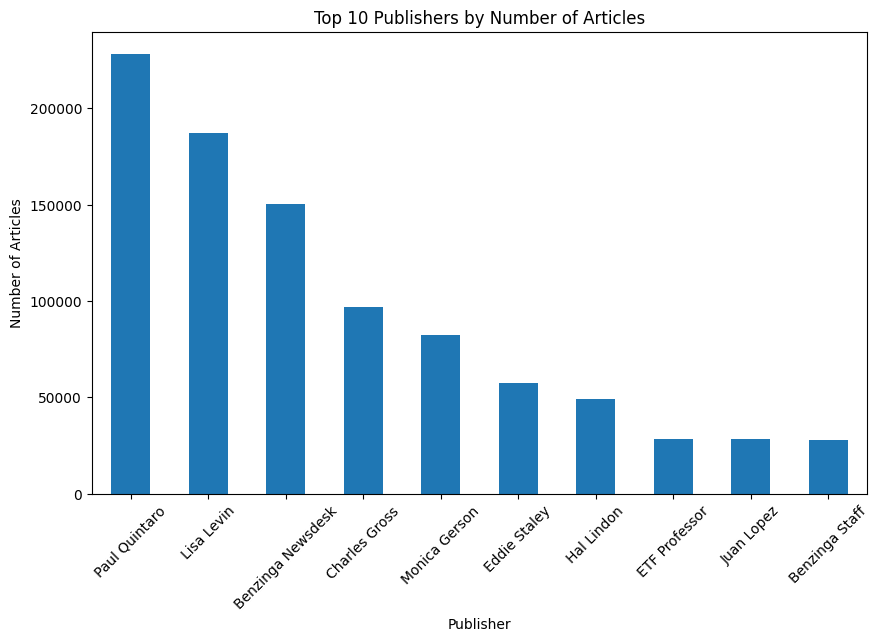

In [13]:
# Count articles per publisher
publisher_counts = df['publisher'].value_counts()

# Top 10 publishers
publisher_counts.head(10)

# Bar plot
plt.figure(figsize=(10, 6))
publisher_counts.head(10).plot(kind='bar')
plt.title('Top 10 Publishers by Number of Articles')
plt.ylabel('Number of Articles')
plt.xlabel('Publisher')
plt.xticks(rotation=45)
plt.show()


In [15]:
# Convert to datetime safely
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

# Optional: drop rows where date could not be parsed
df = df.dropna(subset=['date'])

# Extract date (no time)
df['date_only'] = df['date'].dt.date


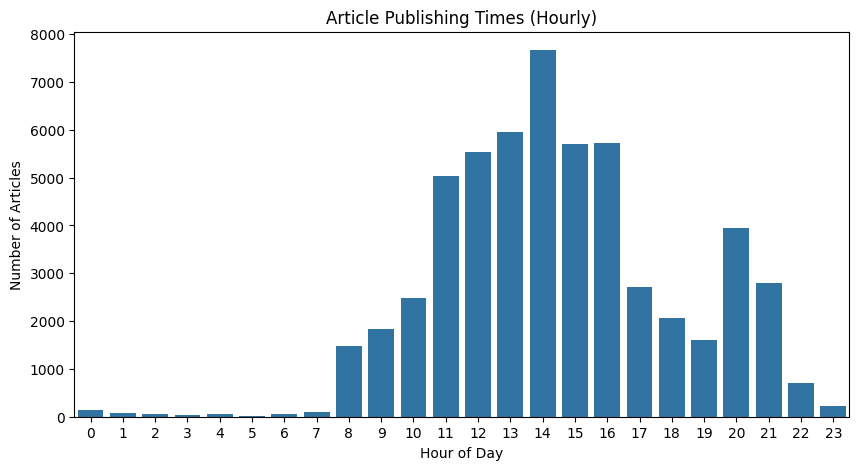

In [16]:
df['hour'] = df['date'].dt.hour

# Plot publishing time distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='hour', data=df)
plt.title('Article Publishing Times (Hourly)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Articles')
plt.show()


In [17]:
# Extract domain if publisher is email
df['email_domain'] = df['publisher'].str.extract(r'@([\w\.-]+)')

# Most common domains (if any)
df['email_domain'].value_counts().head(10)


email_domain
benzinga.com    1196
gmail.com          3
Name: count, dtype: int64

In [18]:
# Convert headlines to lowercase
df['headline_clean'] = df['headline'].str.lower()

# Simple keyword analysis
keywords = ['approval', 'merger', 'acquisition', 'target price', 'IPO']
for keyword in keywords:
    count = df['headline_clean'].str.contains(keyword).sum()
    print(f"'{keyword}' found in {count} headlines")


'approval' found in 319 headlines
'merger' found in 597 headlines
'acquisition' found in 535 headlines
'target price' found in 2 headlines
'IPO' found in 0 headlines


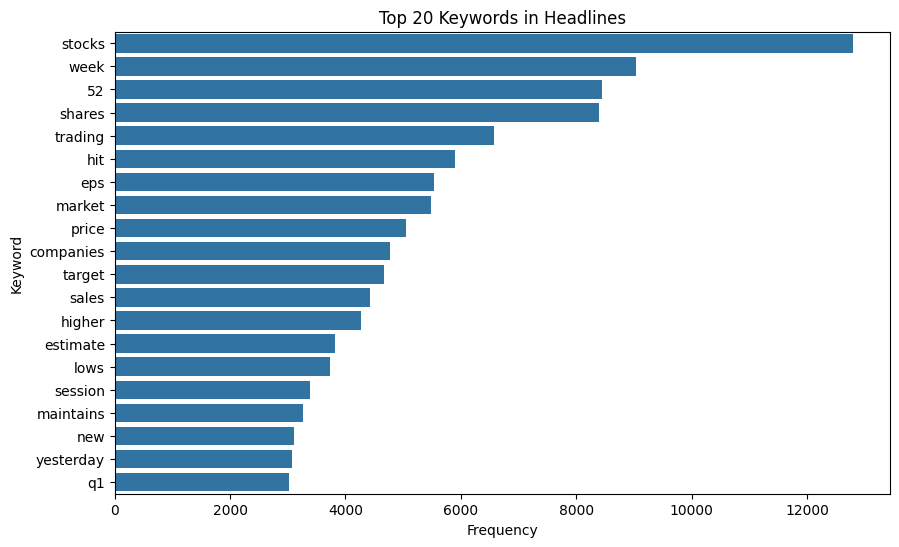

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

# Remove stopwords, tokenize
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df['headline_clean'].dropna())

# Get top words
sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Plot top 20 words
top_words = words_freq[:20]
words, freqs = zip(*top_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(freqs), y=list(words))
plt.title('Top 20 Keywords in Headlines')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.show()


In [22]:
df.to_csv(r'C:\Users\Rahel\Desktop\KAIM 5&6\week 1\Predicting-Stock-Price-Movement-from-Financial-News-Sentiment\data\fnspid_cleaned.csv', index=False)
